In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# Load dataset
df = pd.read_csv("../data/Loan-Approval-Prediction.csv")

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [13]:
# Drop ID column (not useful for prediction)
df.drop("Loan_ID", axis=1, inplace=True)

# Check missing values
df.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [15]:
# Numerical columns → fill with MEAN
num_cols = ["LoanAmount", "Loan_Amount_Term", "Credit_History"]

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

# Categorical columns → fill with MODE
cat_cols = ["Gender", "Married", "Dependents", "Self_Employed"]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [16]:
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [17]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y


In [18]:
df["Dependents"] = df["Dependents"].replace("3+", "3")
df["Dependents"] = df["Dependents"].astype(int)
df["Loan_Status"] = df["Loan_Status"].map({"Y": 1, "N": 0})
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})
df["Married"] = df["Married"].map({"Yes": 1, "No": 0})
df["Self_Employed"] = df["Self_Employed"].map({"Yes": 1, "No": 0})
df["Education"] = df["Education"].map({"Graduate": 1, "Not Graduate": 0})
df["Property_Area"] = df["Property_Area"].map({
    "Rural": 0,
    "Semiurban": 1,
    "Urban": 2
})

In [21]:
df.dtypes

Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
dtype: object

In [22]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

print(X.columns)

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='str')


In [23]:
features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History",
    "Dependents"
]

X = X[features]

X.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Dependents
0,5849,0.0,146.412162,360.0,1.0,0
1,4583,1508.0,128.000000,360.0,1.0,1
2,3000,0.0,66.000000,360.0,1.0,0
3,2583,2358.0,120.000000,360.0,1.0,0
4,6000,0.0,141.000000,360.0,1.0,0


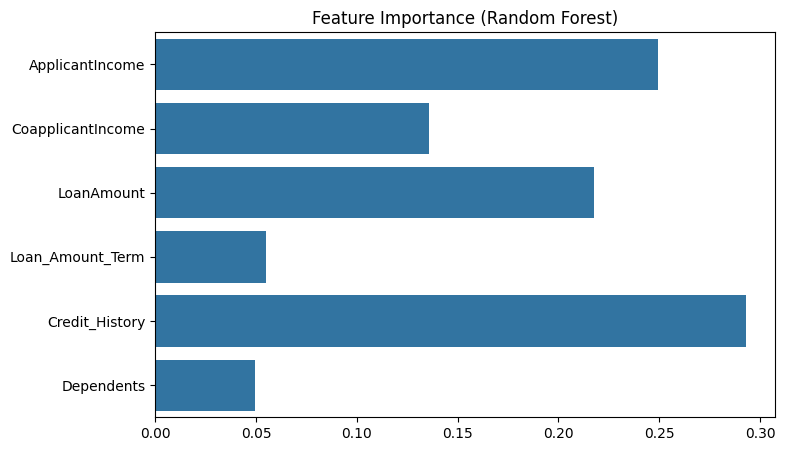

In [24]:
temp_model = RandomForestClassifier(random_state=42)
temp_model.fit(X, y)

importances = temp_model.feature_importances_

plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance (Random Forest)")
plt.show()

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
X_train.shape, X_test.shape

((491, 6), (123, 6))

In [26]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [28]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.7723577235772358


In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[21 22]
 [ 6 74]]


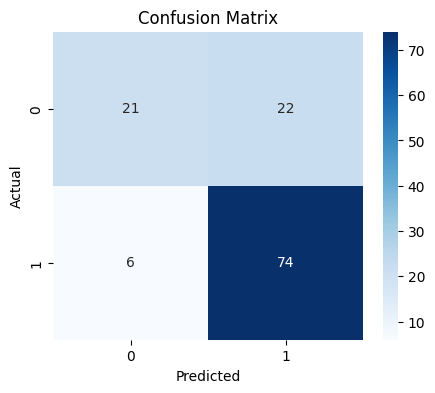

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [31]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.8409090909090909


In [32]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.7708333333333334
Recall: 0.925


In [33]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.7578488372093023


In [34]:
from sklearn.metrics import classification_report

classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.78      0.49      0.60        43\n           1       0.77      0.93      0.84        80\n\n    accuracy                           0.77       123\n   macro avg       0.77      0.71      0.72       123\nweighted avg       0.77      0.77      0.76       123\n'

In [55]:
import joblib
joblib.dump(model, "../models/loan_credit_model.pkl")

['../models/loan_credit_model.pkl']

In [57]:
joblib.dump(X.columns.tolist(), "../models/features.pkl")

['../models/features.pkl']

In [58]:
plt.savefig("../images/feature_importance.png")

<Figure size 640x480 with 0 Axes>